# Gen11 Brakes — Combined Thermal Analysis

Unified Jupyter notebook for both operating cases:
- **Case A — 1g Dynamic Braking** (from `1g dynamic.py`) — transient stop $v_0 \to 0$
- **Case B — Continuous Downhill** (from `continuous downhill.py`) — steady-speed grade holding

All calculations are **front total + rear total**. Vehicle has **2 wheels front, 1 wheel rear**.
Ideal distribution assumes braking force split proportional to dynamic normal loads.

Run all cells top-to-bottom after editing the shared **Vehicle Inputs** cell.

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

g = 9.81
print("imports ok — g =", g)

imports ok — g = 9.81


## Shared Vehicle Inputs (edit once, used by both cases)

From **Gen 11 Mechanical VDR, 2025-26.docx**: $w=281\,kg, wb=2.30\,m, z_{cog}=47.30\,cm$

In [8]:
# ── SHARED VEHICLE (from Gen 11 Mechanical VDR, 2025-26.docx) ──
total_mass = 281.0              # kg
static_mass_front = 183.0       # kg
static_mass_rear = 98.0         # kg  (front+rear must = total)
axle_distance = 2.30            # m wheelbase L
cog_height = 0.473              # m CoG height h (47.30 cm)

# ── CASE A: 1g dynamic ──
initial_speed = 30.0   # m/s
final_speed = 0.0      # m/s
decel = 9.81  # or 1g  # m/s^2

# ── CASE B: continuous downhill ──
constant_speed = 25.0        # m/s steady
downhill_angle = 15.0        # degrees
downhill_distance = 2000.0   # m along slope

# derived geometry (shared)
total_weight = total_mass * g
front_to_cog = axle_distance * static_mass_rear / total_mass
rear_to_cog  = axle_distance - front_to_cog
print(f"Vehicle: {total_mass} kg  L={axle_distance}m  h={cog_height:.4f}m  front_to_cog={front_to_cog:.3f}m rear_to_cog={rear_to_cog:.3f}m")
print(f"Case A: {initial_speed}→{final_speed} m/s @ {decel/g:.2f}g")
print(f"Case B: {constant_speed} m/s @ {downhill_angle}° for {downhill_distance/1000:.1f} km")

Vehicle: 281.0 kg  L=2.3m  h=0.4730m  front_to_cog=0.802m rear_to_cog=1.498m
Case A: 30.0→0.0 m/s @ 1.00g
Case B: 25.0 m/s @ 15.0° for 2.0 km


## Case A — 1g Dynamic Braking

$F_1 = (W\cdot b_{rear} + m a h)/L$

In [9]:
energy_change = 0.5*total_mass*(initial_speed**2 - final_speed**2)
braking_force_total_A = total_mass * decel
t_stop = (initial_speed-final_speed)/decel
avg_power_A = energy_change / t_stop

N1_A = (total_weight*rear_to_cog + total_mass*decel*cog_height)/axle_distance
N2_A = total_weight - N1_A
B1_A = braking_force_total_A * N1_A/total_weight
B2_A = braking_force_total_A - B1_A

print("--- Braking Force Distribution ---")
print(f"Front: {B1_A:,.0f} N ({B1_A/braking_force_total_A*100:.1f}%)")
print(f"Rear:  {B2_A:,.0f} N ({B2_A/braking_force_total_A*100:.1f}%)")
print(f"Total: {braking_force_total_A:,.0f} N")

print("--- Power (Heating) ---")
print(f"Front: {avg_power_A * B1_A / braking_force_total_A / 1000:.1f} kW")
print(f"Rear:  {avg_power_A * B2_A / braking_force_total_A / 1000:.1f} kW")
print(f"Total: {avg_power_A/1000:.1f} kW")

print("\n--- Per Wheel ---")
print(f"Front (each): {B1_A/2:,.0f} N, {avg_power_A * B1_A / braking_force_total_A / 2 / 1000:.1f} kW")
print(f"Rear (single): {B2_A:,.0f} N, {avg_power_A * B2_A / braking_force_total_A / 1000:.1f} kW")


--- Braking Force Distribution ---
Front: 2,362 N (85.7%)
Rear:  394 N (14.3%)
Total: 2,757 N
--- Power (Heating) ---
Front: 35.4 kW
Rear:  5.9 kW
Total: 41.3 kW

--- Per Wheel ---
Front (each): 1,181 N, 17.7 kW
Rear (single): 394 N, 5.9 kW


## Case B — Continuous Downhill (steady speed)

$N_1=(W\cos\theta\cdot b + W\sin\theta\cdot h)/L$

In [10]:
th = math.radians(downhill_angle)
Wn = total_weight*math.cos(th)
Wp = total_weight*math.sin(th)
Btot_B = Wp
Ptot_B = Btot_B * constant_speed
t_desc = downhill_distance/constant_speed

N1_B = (total_weight*math.cos(th)*rear_to_cog + total_weight*math.sin(th)*cog_height)/axle_distance
N2_B = Wn - N1_B
B1_B = Btot_B * N1_B / Wn
B2_B = Btot_B - B1_B
P1_B = Ptot_B * N1_B / Wn
P2_B = Ptot_B - P1_B

print("--- Braking Force Distribution ---")
print(f"Front: {B1_B:,.0f} N ({B1_B/Btot_B*100:.1f}%)")
print(f"Rear:  {B2_B:,.0f} N ({B2_B/Btot_B*100:.1f}%)")
print(f"Total: {Btot_B:,.0f} N")

print("--- Power (Heating) ---")
print(f"Front: {P1_B/1000:.2f} kW ({P1_B/Ptot_B*100:.1f}%)")
print(f"Rear:  {P2_B/1000:.2f} kW ({P2_B/Ptot_B*100:.1f}%)")
print(f"Total: {Ptot_B/1000:.2f} kW")

print("\n--- Per Wheel ---")
print(f"Front (each): {B1_B/2:,.0f} N, {P1_B/2/1000:.2f} kW")
print(f"Rear (single): {B2_B:,.0f} N, {P2_B/1000:.2f} kW")


--- Braking Force Distribution ---
Front: 504 N (70.6%)
Rear:  210 N (29.4%)
Total: 713 N
--- Power (Heating) ---
Front: 12.60 kW (70.6%)
Rear:  5.24 kW (29.4%)
Total: 17.84 kW

--- Per Wheel ---
Front (each): 252 N, 6.30 kW
Rear (single): 210 N, 5.24 kW


## Comparison Plots

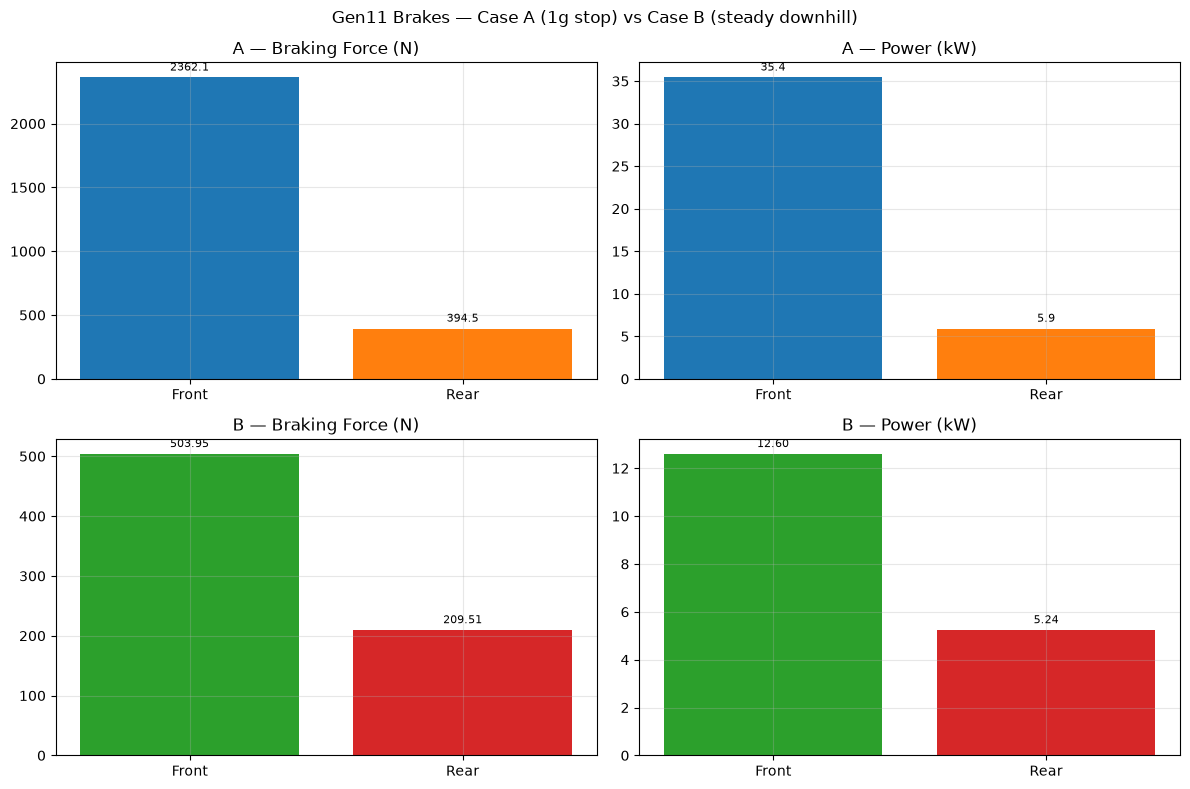

A front bias: 85.7%  |  B front bias: 70.6%
A avg power: 41.3 kW for 3.1s  |  B continuous: 17.84 kW for 1.3 min


In [11]:
labels = ['Front', 'Rear']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Row 1: Case A
axes[0,0].bar(labels, [B1_A, B2_A], color=['#1f77b4','#ff7f0e'])
axes[0,0].set_title('A — Braking Force (N)')
axes[0,1].bar(labels, [avg_power_A * B1_A / braking_force_total_A / 1000, avg_power_A * B2_A / braking_force_total_A / 1000], color=['#1f77b4','#ff7f0e'])
axes[0,1].set_title('A — Power (kW)')
for ax in axes[0]:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f', padding=3, fontsize=8)

# Row 2: Case B
axes[1,0].bar(labels, [B1_B, B2_B], color=['#2ca02c','#d62728'])
axes[1,0].set_title('B — Braking Force (N)')
axes[1,1].bar(labels, [P1_B/1000, P2_B/1000], color=['#2ca02c','#d62728'])
axes[1,1].set_title('B — Power (kW)')
for ax in axes[1]:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', padding=3, fontsize=8)

fig.suptitle('Gen11 Brakes — Case A (1g stop) vs Case B (steady downhill)' , fontsize=12)
plt.tight_layout()
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
plt.show()

print(f"A front bias: {B1_A/braking_force_total_A*100:.1f}%  |  B front bias: {B1_B/Btot_B*100:.1f}%")
print(f"A avg power: {avg_power_A/1000:.1f} kW for {t_stop:.1f}s  |  B continuous: {Ptot_B/1000:.2f} kW for {t_desc/60:.1f} min")


## SolidWorks Transient Thermal Inputs — All 3 Cases

Enter parameters below (sliders) → tables auto-generate for the **front rotor (per rotor)** and the **rear rotor**.
No CSV files — read/copy the numbers straight from the tables.

| Case | Speed profile | Heat power P(t) | Convection h(t) | SolidWorks study |
|---|---|---|---|---|
| **A — 1g stop** | 30 → 0 m/s | `B·v(t)/2`, peaks 35.4 kW/rotor | follows v(t) | Transient 3.06 s — time curves |
| **B — Downhill** | 25 m/s const | 6.3 kW/rotor const | h @ 25 m/s const | Steady-state (or flat curve, 80 s) |
| **C — Duty cycle** | 0.2g accel / 1g brake ×3 | pulses, 0 while accelerating | follows v(t), floor at standstill | Transient ≈ 55 s — time curves |

h correlations (from `Avg h Calculation.xlsx`):
- **h_flat** — laminar flat plate `Nu = 0.664·Re^0.5·Pr^(1/3)` → 43.98 @ 30 m/s (Pr = 0.707)
- **h_cyl** — cylinder crossflow anchors from the Excel (11.58 / 12.38 @ 30 m/s), exact at 6/15/20/30 m/s, power-law interpolation between
- **h_avg** — mean of the two (close to the ~22 W/m²K used in earlier sims)
- A natural-convection floor (default 3 W/m²K) applies at standstill

Requires `ipywidgets`; without it the three default tables simply print.

In [12]:
# ====================================================================
#  SOLIDWORKS TRANSIENT TABLES - ALL 3 CASES (front rotor + rear rotor)
#  Enter parameters below (sliders) -> tables auto-generate.
#  SolidWorks: Thermal loads -> Heat Power -> Time Curve  (t, P column)
#              Thermal loads -> Convection  -> Time Curve  (t, h column)
# ====================================================================
import math
import matplotlib.pyplot as plt

# -- air properties (from Avg h Calculation.xlsx) --
RHO   = 1.225     # kg/m^3
MU    = 1.81e-5   # kg/(m*s)
K_AIR = 0.0263    # W/m-K
D_REF = 0.254     # m rotor diameter the Excel h values were computed at


def _gv(name, default):
    """grab a variable from the notebook namespace if it exists"""
    return globals()[name] if name in globals() else default


def h_flat_plate(v, D=D_REF, Pr=0.707):
    """laminar flat plate: Nu = 0.664 Re^0.5 Pr^(1/3) -> 43.98 @ 30 m/s (D=.254, Pr=.707)"""
    if v <= 0:
        return 0.0
    Re = RHO * v * D / MU
    return 0.664 * math.sqrt(Re) * Pr ** (1.0 / 3.0) * K_AIR / D


# cylinder-in-crossflow anchors copied from 'Avg h Calculation.xlsx' sheet 1
# (exact at 6/15/20/30 m/s, power-law interpolation between, extrapolation outside)
_H_CYL = {0.6:   [(6.0, 6.48), (15.0, 9.20), (20.0, 10.16), (30.0, 11.58)],
          0.707: [(6.0, 6.92), (15.0, 9.83), (20.0, 10.86), (30.0, 12.38)]}


def _anchor_h(v, pts):
    """piecewise power-law interpolation through anchor points"""
    vs = [p[0] for p in pts]
    hs = [p[1] for p in pts]
    if v <= vs[0]:
        b = math.log(hs[1] / hs[0]) / math.log(vs[1] / vs[0])
        return hs[0] * (v / vs[0]) ** b if v > 0 else 0.0
    if v >= vs[-1]:
        b = math.log(hs[-1] / hs[-2]) / math.log(vs[-1] / vs[-2])
        return hs[-1] * (v / vs[-1]) ** b
    for i in range(len(vs) - 1):
        if vs[i] <= v <= vs[i + 1]:
            b = math.log(hs[i + 1] / hs[i]) / math.log(vs[i + 1] / vs[i])
            return hs[i] * (v / vs[i]) ** b


def h_cylinder(v, D=D_REF, Pr=0.707):
    """cylinder crossflow h from the Excel anchors (exact at 6/15/20/30 m/s)"""
    if v <= 0:
        return 0.0
    h6 = _anchor_h(v, _H_CYL[0.6])
    h7 = _anchor_h(v, _H_CYL[0.707])
    if Pr < 0.6:
        h = h6 * (Pr / 0.6) ** (1.0 / 3.0)
    elif Pr > 0.707:
        h = h7 * (Pr / 0.707) ** (1.0 / 3.0)
    else:
        w = (Pr - 0.6) / 0.107
        h = (1.0 - w) * h6 + w * h7
    return h * math.sqrt(D_REF / D)


def h_avg(v, D=D_REF, Pr=0.707):
    """mean of flat-plate and cylinder correlations"""
    return 0.5 * (h_flat_plate(v, D, Pr) + h_cylinder(v, D, Pr))


def _h_any(v, corr, D, Pr, floor):
    """correlation value with a natural-convection floor near standstill"""
    return max(corr(v, D, Pr), floor)


def _trapz(ys, ts):
    return sum((ys[i] + ys[i + 1]) * 0.5 * (ts[i + 1] - ts[i]) for i in range(len(ts) - 1))


def _print_table(rows):
    hdr = (f"{'t [s]':>7}  {'v [m/s]':>8}  {'P_front/rotor [W]':>18}  "
           f"{'P_rear [W]':>12}  {'h_flat':>8}  {'h_cyl':>8}  {'h_avg':>8}")
    print(hdr)
    print("-" * len(hdr))
    for t, v, p_f, p_r, h_f, h_c, h_a in rows:
        print(f"{t:>7.2f}  {v:>8.2f}  {p_f:>18,.0f}  {p_r:>12,.0f}  {h_f:>8.2f}  {h_c:>8.2f}  {h_a:>8.2f}")
    print("-" * len(hdr))


def _plot_ph(rows, title):
    ts = [r[0] for r in rows]
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(ts, [r[2] / 1000 for r in rows], "b-", label="P front/rotor [kW]")
    ax1.plot(ts, [r[3] / 1000 for r in rows], "c--", label="P rear [kW]")
    ax1.set_xlabel("t [s]")
    ax1.set_ylabel("P [kW]", color="b")
    ax1.tick_params(axis="y", labelcolor="b")
    ax1.grid(alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(ts, [r[4] for r in rows], "r-", label="h_flat")
    ax2.plot(ts, [r[5] for r in rows], "m--", label="h_cyl")
    ax2.plot(ts, [r[6] for r in rows], "o-", ms=2, label="h_avg")
    ax2.set_ylabel("h [W/m2K]", color="r")
    ax2.tick_params(axis="y", labelcolor="r")
    ax1.set_title(title)
    fig.tight_layout()
    plt.show()


# --------------------------------------------------------------------
# CASE A - 1g stop: P(t) and h(t) step down together
# --------------------------------------------------------------------
def run_caseA(v0=30.0, decel=9.81, B_front_total=None, B_rear=None,
              D=0.254, Pr=0.707, dt=0.1, h_floor=3.0):
    B_front_total = B_front_total if B_front_total is not None else _gv("B1_A", 2362.0)
    B_rear = B_rear if B_rear is not None else _gv("B2_A", 394.0)
    Bf = B_front_total / 2.0                     # per front rotor (2 front rotors)
    t_stop = v0 / decel
    times = [round(i * dt, 10) for i in range(int(math.ceil(t_stop / dt)))]
    if abs(times[-1] - t_stop) > 1e-9:
        times.append(round(t_stop, 10))
    rows = []
    for t in times:
        v = max(v0 - decel * t, 0.0)
        rows.append((t, v, Bf * v, B_rear * v,
                     _h_any(v, h_flat_plate, D, Pr, h_floor),
                     _h_any(v, h_cylinder, D, Pr, h_floor),
                     _h_any(v, h_avg, D, Pr, h_floor)))
    print(f"CASE A - 1g stop: {v0:.1f} -> 0 m/s @ {decel:.2f} m/s2 ({t_stop:.2f} s)   "
          f"B_front_total = {B_front_total:,.0f} N ({Bf:,.0f} N/rotor)   B_rear = {B_rear:,.0f} N")
    _print_table(rows)
    ts = [r[0] for r in rows]
    E_f = _trapz([r[2] for r in rows], ts)
    E_r = _trapz([r[3] for r in rows], ts)
    print(f"peak P_front/rotor = {rows[0][2]:,.0f} W   |   time-avg = {E_f / t_stop / 1000:.2f} kW   |   "
          f"E_front/rotor = {E_f / 1000:.1f} kJ   |   E_rear = {E_r / 1000:.1f} kJ")
    _plot_ph(rows, f"Case A - {v0:.0f} -> 0 m/s @ {decel:.2f} m/s2 (per front rotor + rear)")
    return rows


# --------------------------------------------------------------------
# CASE B - steady downhill: constant speed -> constant P and h
# --------------------------------------------------------------------
def run_caseB(speed=None, angle=None, distance=None, D=0.254, Pr=0.707, h_floor=3.0):
    speed = speed if speed is not None else _gv("constant_speed", 25.0)
    angle = angle if angle is not None else _gv("downhill_angle", 15.0)
    distance = distance if distance is not None else _gv("downhill_distance", 2000.0)
    W = _gv("total_weight", 281.0 * 9.81)
    b = _gv("rear_to_cog", 1.498)
    hcg = _gv("cog_height", 0.473)
    L = _gv("axle_distance", 2.30)
    th = math.radians(angle)
    Wn = W * math.cos(th)
    Wp = W * math.sin(th)
    N1 = (Wn * b + Wp * hcg) / L
    N2 = Wn - N1
    B_f = Wp * N1 / Wn / 2.0                     # braking force per front rotor (2 front rotors)
    B_r = Wp * N2 / Wn                           # braking force, rear (single rotor)
    P_f = B_f * speed                            # heat power per front rotor
    P_r = B_r * speed
    t_desc = distance / speed
    h_f = _h_any(speed, h_flat_plate, D, Pr, h_floor)
    h_c = _h_any(speed, h_cylinder, D, Pr, h_floor)
    h_a = 0.5 * (h_f + h_c)
    rows = [(0.0, speed, P_f, P_r, h_f, h_c, h_a),
            (round(t_desc, 4), speed, P_f, P_r, h_f, h_c, h_a)]
    print(f"CASE B - steady downhill: {speed:.1f} m/s @ {angle:.1f} deg for {t_desc:.0f} s   "
          f"(front bias {N1 / Wn * 100:.1f}%)")
    print("constant values -> SolidWorks Steady-State study, or paste as a flat time curve:")
    _print_table(rows)
    print(f"P_front/rotor = {P_f:,.0f} W   |   P_rear = {P_r:,.0f} W   |   "
          f"E_front/rotor = {P_f * t_desc / 1000:.1f} kJ   |   E_rear = {P_r * t_desc / 1000:.1f} kJ")
    return rows


# --------------------------------------------------------------------
# CASE C - repeated duty cycle: 0.2g accel (no heat) / 1g brake pulses
# --------------------------------------------------------------------
def run_caseC(n_cycles=3, accel_g=0.20, v0=30.0, decel=9.81, rest=0.0,
              D=0.254, Pr=0.707, dt=0.1, h_floor=3.0,
              B_front_total=None, B_rear=None):
    B_front_total = B_front_total if B_front_total is not None else _gv("B1_A", 2362.0)
    B_rear = B_rear if B_rear is not None else _gv("B2_A", 394.0)
    Bf = B_front_total / 2.0
    accel = accel_g * 9.81
    t_a = v0 / accel
    t_b = v0 / decel
    cycle = t_a + t_b + rest
    rows = []
    for c in range(n_cycles):
        t0 = round(c * cycle, 10)
        # accelerate 0 -> v0: no braking heat, h follows the rising speed
        for i in range(int(math.ceil(t_a / dt))):
            t = round(t0 + i * dt, 10)
            v = accel * (t - t0)
            rows.append((t, v, 0.0, 0.0,
                         _h_any(v, h_flat_plate, D, Pr, h_floor),
                         _h_any(v, h_cylinder, D, Pr, h_floor),
                         _h_any(v, h_avg, D, Pr, h_floor)))
        # brake v0 -> 0: P and h decay together
        for i in range(int(math.ceil(t_b / dt))):
            t = round(t0 + t_a + i * dt, 10)
            v = max(v0 - decel * i * dt, 0.0)
            rows.append((t, v, Bf * v, B_rear * v,
                         _h_any(v, h_flat_plate, D, Pr, h_floor),
                         _h_any(v, h_cylinder, D, Pr, h_floor),
                         _h_any(v, h_avg, D, Pr, h_floor)))
        if abs(rows[-1][0] - round(t0 + t_a + t_b, 10)) > 1e-9:
            rows.append((round(t0 + t_a + t_b, 10), 0.0, 0.0, 0.0, h_floor, h_floor, h_floor))
        # optional standstill rest between cycles
        if rest > 0:
            for i in range(1, int(round(rest / dt)) + 1):
                if i * dt <= rest + 1e-9:
                    t = round(t0 + t_a + t_b + i * dt, 10)
                    rows.append((t, 0.0, 0.0, 0.0, h_floor, h_floor, h_floor))
    total = n_cycles * cycle
    print(f"CASE C - repeated duty cycle: {n_cycles} x [accel {accel_g:.2f}g -> {v0:.0f} m/s in {t_a:.2f} s "
          f"+ brake @ {decel:.2f} m/s2 in {t_b:.2f} s]   rest = {rest:.0f} s   total = {total:.2f} s")
    _print_table(rows)
    E_f = n_cycles * Bf * v0 ** 2 / (2.0 * decel)        # exact (brake pulses only)
    E_r = n_cycles * B_rear * v0 ** 2 / (2.0 * decel)
    print(f"peak P_front/rotor = {max(r[2] for r in rows):,.0f} W   |   "
          f"E_front/rotor = {E_f / 1000:.1f} kJ   |   E_rear = {E_r / 1000:.1f} kJ   |   "
          f"avg P_front = {E_f / total / 1000:.2f} kW")
    _plot_ph(rows, f"Case C - {n_cycles} cycles ({accel_g:.2f}g accel / {decel / 9.81:.2f}g brake)")
    return rows


# --------------------------------------------------------------------
# interactive controls (falls back to default tables without ipywidgets)
# --------------------------------------------------------------------
if HAS_WIDGETS:
    _a_w = {
        "v0":            widgets.FloatSlider(value=float(_gv("initial_speed", 30.0)), min=1.0, max=60.0, step=0.5, description="v0 [m/s]", continuous_update=False),
        "decel":         widgets.FloatSlider(value=float(_gv("decel", 9.81)), min=1.0, max=15.0, step=0.01, description="decel [m/s2]", readout_format=".2f", continuous_update=False),
        "B_front_total": widgets.FloatSlider(value=float(_gv("B1_A", 2362.0)), min=500.0, max=6000.0, step=10.0, description="B_front [N]", continuous_update=False),
        "B_rear":        widgets.FloatSlider(value=float(_gv("B2_A", 394.0)), min=50.0, max=2000.0, step=5.0, description="B_rear [N]", continuous_update=False),
        "D":             widgets.FloatSlider(value=0.254, min=0.10, max=0.40, step=0.001, description="D [m]", readout_format=".3f", continuous_update=False),
        "Pr":            widgets.FloatSlider(value=0.707, min=0.60, max=0.75, step=0.001, description="Pr", readout_format=".3f", continuous_update=False),
        "dt":            widgets.FloatSlider(value=0.1, min=0.02, max=0.50, step=0.01, description="dt [s]", readout_format=".2f", continuous_update=False),
        "h_floor":       widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.5, description="h floor", readout_format=".1f", continuous_update=False),
    }
    _a_out = widgets.interactive_output(run_caseA, _a_w)
    display(Markdown("### Case A - 1g stop (per front rotor + rear)"), widgets.VBox(list(_a_w.values())), _a_out)

    _b_w = {
        "speed":    widgets.FloatSlider(value=float(_gv("constant_speed", 25.0)), min=5.0, max=40.0, step=0.5, description="speed [m/s]", continuous_update=False),
        "angle":    widgets.FloatSlider(value=float(_gv("downhill_angle", 15.0)), min=5.0, max=30.0, step=0.5, description="angle [deg]", continuous_update=False),
        "distance": widgets.FloatSlider(value=float(_gv("downhill_distance", 2000.0)), min=500.0, max=5000.0, step=100.0, description="distance [m]", continuous_update=False),
        "D":        widgets.FloatSlider(value=0.254, min=0.10, max=0.40, step=0.001, description="D [m]", readout_format=".3f", continuous_update=False),
        "Pr":       widgets.FloatSlider(value=0.707, min=0.60, max=0.75, step=0.001, description="Pr", readout_format=".3f", continuous_update=False),
        "h_floor":  widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.5, description="h floor", readout_format=".1f", continuous_update=False),
    }
    _b_out = widgets.interactive_output(run_caseB, _b_w)
    display(Markdown("### Case B - steady downhill (constant)"), widgets.VBox(list(_b_w.values())), _b_out)

    _c_w = {
        "n_cycles": widgets.IntSlider(value=3, min=1, max=10, step=1, description="cycles", continuous_update=False),
        "accel_g":  widgets.FloatSlider(value=0.20, min=0.05, max=0.50, step=0.01, description="accel [g]", readout_format=".2f", continuous_update=False),
        "v0":       widgets.FloatSlider(value=30.0, min=10.0, max=60.0, step=1.0, description="v0 [m/s]", continuous_update=False),
        "decel":    widgets.FloatSlider(value=9.81, min=5.0, max=15.0, step=0.01, description="decel [m/s2]", readout_format=".2f", continuous_update=False),
        "rest":     widgets.FloatSlider(value=0.0, min=0.0, max=30.0, step=1.0, description="rest [s]", readout_format=".0f", continuous_update=False),
        "D":        widgets.FloatSlider(value=0.254, min=0.10, max=0.40, step=0.001, description="D [m]", readout_format=".3f", continuous_update=False),
        "Pr":       widgets.FloatSlider(value=0.707, min=0.60, max=0.75, step=0.001, description="Pr", readout_format=".3f", continuous_update=False),
        "dt":       widgets.FloatSlider(value=0.1, min=0.05, max=0.50, step=0.05, description="dt [s]", readout_format=".2f", continuous_update=False),
        "h_floor":  widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.5, description="h floor", readout_format=".1f", continuous_update=False),
    }
    _c_out = widgets.interactive_output(run_caseC, _c_w)
    display(Markdown("### Case C - repeated duty cycle"), widgets.VBox(list(_c_w.values())), _c_out)
else:
    run_caseA()
    run_caseB()
    run_caseC()

### Case A - 1g stop (per front rotor + rear)

Output()

### Case B - steady downhill (constant)

Output()

### Case C - repeated duty cycle

Output()